In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Datensatz laden und Exploration

In [2]:
df = pd.read_csv("movie_metadata.csv", sep=",")

In [3]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [4]:
df.shape

(5043, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [6]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

gross                        884
budget                       492
aspect_ratio                 329
content_rating               303
plot_keywords                153
title_year                   108
director_facebook_likes      104
director_name                104
num_critic_for_reviews        50
actor_3_facebook_likes        23
actor_3_name                  23
num_user_for_reviews          21
color                         19
duration                      15
language                      14
actor_2_facebook_likes        13
actor_2_name                  13
facenumber_in_poster          13
actor_1_name                   7
actor_1_facebook_likes         7
country                        5
genres                         0
movie_title                    0
cast_total_facebook_likes      0
movie_imdb_link                0
num_voted_users                0
imdb_score                     0
movie_facebook_likes           0
dtype: int64

## Kategorische Spalten

In [8]:
# Kategorien zählen
categorical_columns = df.select_dtypes(include='object').columns

sorted_cols = sorted(
    categorical_columns,
    key=lambda col: df[col].nunique(),
    reverse=True  # höchste Anzahl zuerst
)

for col in sorted_cols:
    print(col, df[col].nunique())

movie_imdb_link 4919
movie_title 4917
plot_keywords 4760
actor_3_name 3521
actor_2_name 3032
director_name 2398
actor_1_name 2097
genres 914
country 65
language 46
content_rating 18
color 2


In [9]:
# Da One-Hot-Encoding zu einer sehr hohen Dimensionalität führen würde und die meisten Kategorien nur selten auftreten, 
# wurden diese Features für das Basismodell entfernt:
# movie_title, plot_keywords, movie_imdb_link, actor_3_name droppen, evtl. auch actor_2_name
df.drop(columns=['movie_title', 'plot_keywords', 'movie_imdb_link', 'actor_3_name', 'actor_2_name', 'director_name', 'actor_1_name'], inplace=True)

In [10]:
df['color'].value_counts()

color
Color               4815
 Black and White     209
Name: count, dtype: int64

In [11]:
# Spalte 'genres' besteht aus einer Kombination von Basisgenres. Daher prüfen wir, wie viele es sind.

unique_genres = set()

for g in df['genres']:
    unique_genres.update(g.split('|'))

print(len(unique_genres))
print(sorted(unique_genres))

26
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']


Die Spalte 'genres' enthält 26 Basisgenres. Statt One-Hot-Encoding bietet sich MultiLabelEncoding an.

## Duplikate entfernen

In [12]:
# Duplikate finden
duplicates = df[df.duplicated()]
print(duplicates)

                 color  num_critic_for_reviews  duration  \
137              Color                   248.0     110.0   
187              Color                   322.0     115.0   
204              Color                     1.0     120.0   
303              Color                   256.0     111.0   
389              Color                   369.0     100.0   
395              Color                   187.0     106.0   
590              Color                   245.0     101.0   
656              Color                   196.0     113.0   
794              Color                   703.0     173.0   
1220             Color                   322.0     137.0   
1305             Color                   159.0     110.0   
1449             Color                   208.0     122.0   
2169             Color                    98.0     114.0   
2292             Color                   168.0      87.0   
2472             Color                    45.0      90.0   
2493   Black and White                  

In [13]:
# Anzahl der Duplikate
df.duplicated().sum()

45

In [14]:
# Duplikate entfernen

df_clean = df.drop_duplicates()

# X und y definieren

In [15]:
# Features
X = df_clean.drop('imdb_score', axis=1)

# Zielvariable
y = df_clean['imdb_score'].copy()

# Data Split in Train, Validation, Test

In [16]:
X_train_full,X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train,X_val,y_train,y_val=train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)
# Ergebnis: 60% Train, 20% Val, 20% Test

# EDA

In [17]:
# Korrelationen
train_df = X_train.copy()
train_df['imdb_score'] = y_train

train_df.corr(numeric_only=True)['imdb_score'].sort_values()

title_year                  -0.213127
facenumber_in_poster        -0.055814
actor_3_facebook_likes       0.043882
budget                       0.045131
actor_1_facebook_likes       0.055397
cast_total_facebook_likes    0.061798
actor_2_facebook_likes       0.062396
aspect_ratio                 0.062641
director_facebook_likes      0.157666
gross                        0.205299
movie_facebook_likes         0.251863
duration                     0.268709
num_user_for_reviews         0.283020
num_critic_for_reviews       0.313432
num_voted_users              0.417236
imdb_score                   1.000000
Name: imdb_score, dtype: float64

Text(0.5, 1.0, 'Korrelationsheatmap')

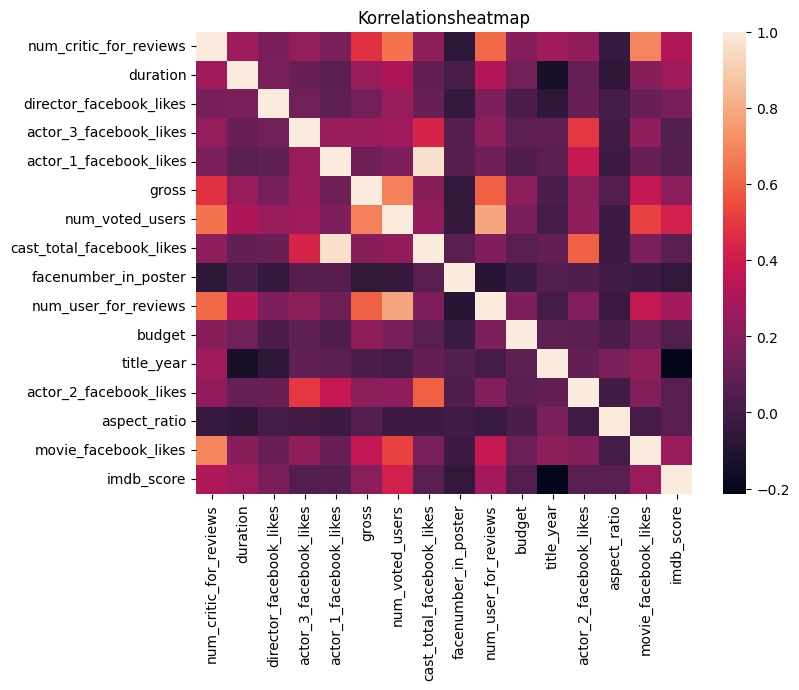

In [18]:
# Heatmap Korrelationen
plt.figure(figsize=(8,6))
sns.heatmap(train_df.corr(numeric_only=True))
plt.title('Korrelationsheatmap')

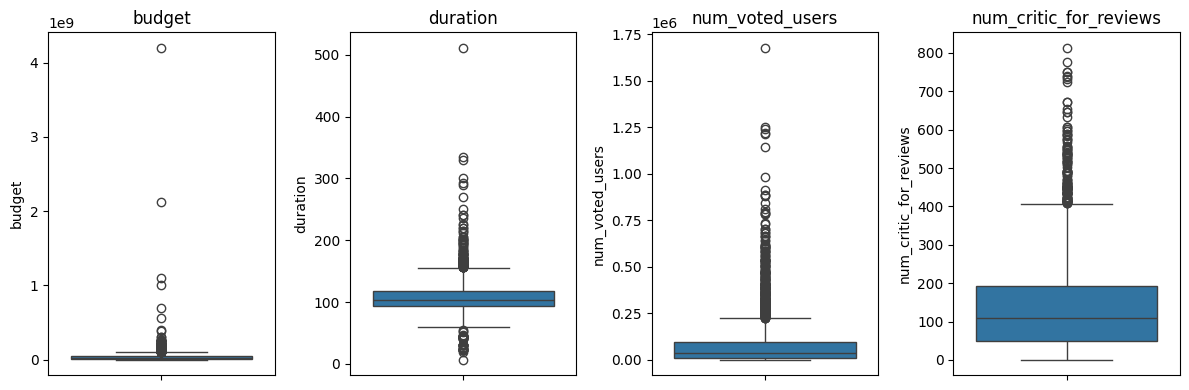

In [19]:
# Boxplots

cols = ['budget', 'duration', 'num_voted_users', 'num_critic_for_reviews']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, col in enumerate(cols):
    sns.boxplot(y=train_df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [20]:
# Prozentualer Anteil an Ausreißern

num_cols = X_train.select_dtypes(include="number").columns

for col in num_cols:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ]

    pct = len(outliers) / len(X_train) * 100

    print(f"{col}: {pct:.2f}% Ausreißer")

num_critic_for_reviews: 4.24% Ausreißer
duration: 4.90% Ausreißer
director_facebook_likes: 11.61% Ausreißer
actor_3_facebook_likes: 3.20% Ausreißer
actor_1_facebook_likes: 3.44% Ausreißer
gross: 6.54% Ausreißer
num_voted_users: 9.44% Ausreißer
cast_total_facebook_likes: 7.17% Ausreißer
facenumber_in_poster: 3.84% Ausreißer
num_user_for_reviews: 8.11% Ausreißer
budget: 6.34% Ausreißer
title_year: 6.94% Ausreißer
actor_2_facebook_likes: 12.31% Ausreißer
aspect_ratio: 0.87% Ausreißer
movie_facebook_likes: 23.05% Ausreißer


# Preprocessing

## Nicht benötigte Features entfernen

In [21]:
'''
oben schon einige entfernt. Die numerischen hier würde ich erst mal behalten.
df = df.drop(columns=[
    "movie_title",
    "movie_imdb_link",
    "plot_keywords",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "facenumber_in_poster",
    "num_user_for_reviews",
    "director_facebook_likes",
    "num_critic_for_reviews"
])
'''

'\noben schon einige entfernt. Die numerischen hier würde ich erst mal behalten.\ndf = df.drop(columns=[\n    "movie_title",\n    "movie_imdb_link",\n    "plot_keywords",\n    "actor_1_facebook_likes",\n    "actor_2_facebook_likes",\n    "actor_3_facebook_likes",\n    "facenumber_in_poster",\n    "num_user_for_reviews",\n    "director_facebook_likes",\n    "num_critic_for_reviews"\n])\n'

## Rare Category Handling

Rare Category Handling (Begründung: Stabilität + Vermeidung von Overfitting)

Schwelle: min_count = 20 (weniger als 20 Beobachtungen → "Other")

In [22]:
min_count = 50

# Country zusammenfassen 

country_counts = X_train["country"].value_counts()
rare_countries = country_counts[country_counts < min_count].index

X_train["country"] = X_train["country"].replace(rare_countries, "Other")
X_test["country"] = X_test["country"].replace(rare_countries, "Other")
X_val["country"] = X_val["country"].replace(rare_countries, "Other")

# Language zusammenfassen
language_counts = X_train["language"].value_counts()
rare_languages = language_counts[language_counts < min_count].index

X_train["language"] = X_train["language"].replace(rare_languages, "Other")
X_test["language"] = X_test["language"].replace(rare_languages, "Other")
X_val["language"] = X_val["language"].replace(rare_languages, "Other")

# Content_rating zusammenfassen
content_rating_counts = X_train["content_rating"].value_counts()
rare_content_rating = content_rating_counts[content_rating_counts < min_count].index

X_train["content_rating"] = X_train["content_rating"].replace(rare_content_rating, "Other")
X_test["content_rating"] = X_test["content_rating"].replace(rare_content_rating, "Other")
X_val["content_rating"] = X_val["content_rating"].replace(rare_content_rating, "Other")

## Genres Multi-Hot-Encoding

Die Spalte "genres" enthält mehrere Genres pro Film. Daher wird Multi-Hot-Encoding verwendet.

In [23]:
# Genres vorbereiten

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

# FIT NUR auf TRAIN
train_genres = mlb.fit_transform(
    X_train["genres"].fillna("").str.split("|")
)

# TRANSFORM auf VAL / TEST
val_genres = mlb.transform(
    X_val["genres"].fillna("").str.split("|")
)

test_genres = mlb.transform(
    X_test["genres"].fillna("").str.split("|")
)

In [24]:
# in Dataframes umwandeln 
train_genres_df = pd.DataFrame(train_genres, columns=mlb.classes_, index=X_train.index)
val_genres_df   = pd.DataFrame(val_genres, columns=mlb.classes_, index=X_val.index)
test_genres_df  = pd.DataFrame(test_genres, columns=mlb.classes_, index=X_test.index)

In [25]:
# genres aus X entfernen
X_train = X_train.drop(columns=["genres"])
X_val   = X_val.drop(columns=["genres"])
X_test  = X_test.drop(columns=["genres"])

In [26]:
# Dataframes zusammenbauen
X_train = pd.concat([X_train, train_genres_df], axis=1)
X_val   = pd.concat([X_val, val_genres_df], axis=1)
X_test  = pd.concat([X_test, test_genres_df], axis=1)

In [27]:
# Spaltennamen von X_train
X_train.columns

Index(['color', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes',
       'actor_1_facebook_likes', 'gross', 'num_voted_users',
       'cast_total_facebook_likes', 'facenumber_in_poster',
       'num_user_for_reviews', 'language', 'country', 'content_rating',
       'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio',
       'movie_facebook_likes', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical',
       'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport',
       'Thriller', 'War', 'Western'],
      dtype='object')

In [28]:
# Info über aktuelles X_train
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 3956 to 4064
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      2988 non-null   object 
 1   num_critic_for_reviews     2971 non-null   float64
 2   duration                   2992 non-null   float64
 3   director_facebook_likes    2944 non-null   float64
 4   actor_3_facebook_likes     2981 non-null   float64
 5   actor_1_facebook_likes     2992 non-null   float64
 6   gross                      2490 non-null   float64
 7   num_voted_users            2998 non-null   int64  
 8   cast_total_facebook_likes  2998 non-null   int64  
 9   facenumber_in_poster       2991 non-null   float64
 10  num_user_for_reviews       2987 non-null   float64
 11  language                   2991 non-null   object 
 12  country                    2996 non-null   object 
 13  content_rating             2829 non-null   object 

## Fehlende Werte behandeln

Numerische Features -> Median 

Kategorische Features -> Modus

In [29]:
num_cols = [
    "duration",
    "gross",
    "budget",
    "aspect_ratio",
    "title_year",
    "movie_facebook_likes",
    "cast_total_facebook_likes",
    "num_critic_for_reviews",
    "director_facebook_likes",
    "actor_3_facebook_likes",
    "actor_1_facebook_likes",
    "facenumber_in_poster",
    "num_user_for_reviews",
    "actor_2_facebook_likes"
]

cat_cols = [
    "color",
    "language",
    "country",
    "content_rating",
]

## Median auf Train berechnen

In [30]:
for col in num_cols:
    
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [31]:
X_train[num_cols].isna().sum().sum()

0

In [32]:
for col in num_cols:
    print(
        col,
        "NaNs:",
        X_train[col].isna().sum(),
        "median:",
        X_train[col].median()
    )

duration NaNs: 0 median: 103.0
gross NaNs: 0 median: 24828919.5
budget NaNs: 0 median: 20000000.0
aspect_ratio NaNs: 0 median: 2.35
title_year NaNs: 0 median: 2005.0
movie_facebook_likes NaNs: 0 median: 166.5
cast_total_facebook_likes NaNs: 0 median: 3012.5
num_critic_for_reviews NaNs: 0 median: 109.0
director_facebook_likes NaNs: 0 median: 49.0
actor_3_facebook_likes NaNs: 0 median: 359.0
actor_1_facebook_likes NaNs: 0 median: 975.0
facenumber_in_poster NaNs: 0 median: 1.0
num_user_for_reviews NaNs: 0 median: 157.0
actor_2_facebook_likes NaNs: 0 median: 581.0


## Mode auf Train berechnen

In [33]:
for col in cat_cols:

    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_val[col] = X_val[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Log Transform

Hier stabilisieren wir stark schiefe Verteilungen (Heavy-Tail Features) mit log_transform.
Skewness misst, wie asymmetrisch eine Verteilung ist.

In [34]:

# Skewness nur auf TRAIN berechnen
skewness = X_train[num_cols].skew()

# Schwelle: > 1 bedeutet stark rechtsschief
skewed_cols = skewness[skewness > 1].index

print("Stark schiefe Spalten:", skewed_cols.tolist())


Stark schiefe Spalten: ['duration', 'gross', 'budget', 'aspect_ratio', 'movie_facebook_likes', 'cast_total_facebook_likes', 'num_critic_for_reviews', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'actor_2_facebook_likes']


## Log Transform after Skewness
Nicht alle schiefen Variablen sind sinnvoll zu transformieren. Deshalb zusätzliche inhaltliche Filterung.

In [35]:


for col in skewed_cols:

    # Log funktioniert nur für nicht-negative Werte - Filtering
    if (X_train[col] < 0).any():
        continue

    # Strukturelle oder begrenzte Variablen nicht transformieren
    # Diese Features sind keine klassischen Heavy-Tail-Variablen
    if col in ["aspect_ratio", "facenumber_in_poster", "duration"]:
        continue

    # Log-Transformation auf alle Datensplits anwenden
    X_train[col] = np.log1p(X_train[col])
    X_val[col]   = np.log1p(X_val[col])
    X_test[col]  = np.log1p(X_test[col])

    print(f"{col} wurde log-transformiert")


gross wurde log-transformiert
budget wurde log-transformiert
movie_facebook_likes wurde log-transformiert
cast_total_facebook_likes wurde log-transformiert
num_critic_for_reviews wurde log-transformiert
director_facebook_likes wurde log-transformiert
actor_3_facebook_likes wurde log-transformiert
actor_1_facebook_likes wurde log-transformiert
num_user_for_reviews wurde log-transformiert
actor_2_facebook_likes wurde log-transformiert


### Check NaN again

In [36]:
print("Train")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("Val")
print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

print("Test")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])


Train
Series([], dtype: int64)
Val
Series([], dtype: int64)
Test
Series([], dtype: int64)


# One-Hot-Encoding
Kategorische Variablen hier numerisch machen:
drop_first=True vermeidet die Dummy-Variable-Falle und reduziert perfekte Multikollinearität.

In [37]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val   = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [38]:
X_train.columns

Index(['num_critic_for_reviews', 'duration', 'director_facebook_likes',
       'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
       'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster',
       'num_user_for_reviews', 'budget', 'title_year',
       'actor_2_facebook_likes', 'aspect_ratio', 'movie_facebook_likes',
       'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show',
       'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News',
       'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War',
       'Western', 'color_Color', 'language_French', 'language_Other',
       'country_France', 'country_Germany', 'country_Other', 'country_UK',
       'country_USA', 'content_rating_Not Rated', 'content_rating_Other',
       'content_rating_PG', 'content_rating_PG-13', 'content_rating_R'],
      dtype='object')

## Reindex
Align Features zwischen Sets nach dem Transformation.

In [39]:
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Scaling
RobustScaler ist stabiler bei Ausreißern und schiefen Verteilungen, die im Movie-Datensatz häufig vorkommen.

In [40]:
from sklearn.preprocessing import RobustScaler

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_val_scaled = X_val.copy()

scaler = RobustScaler()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])

## Korrelationen nach Skalierung

In [41]:
# Korrelationen
train_df_scaled = X_train_scaled[num_cols].copy()
train_df_scaled["imdb_score"] = y_train

train_df_scaled.corr(numeric_only=True)["imdb_score"].sort_values()

title_year                  -0.205814
facenumber_in_poster        -0.055652
actor_3_facebook_likes      -0.053017
actor_2_facebook_likes      -0.012598
budget                       0.007649
cast_total_facebook_likes    0.010394
gross                        0.050362
aspect_ratio                 0.055648
actor_1_facebook_likes       0.057147
movie_facebook_likes         0.101872
director_facebook_likes      0.123695
duration                     0.268201
num_critic_for_reviews       0.298411
num_user_for_reviews         0.303724
imdb_score                   1.000000
Name: imdb_score, dtype: float64

Text(0.5, 1.0, 'Korrelationsheatmap')

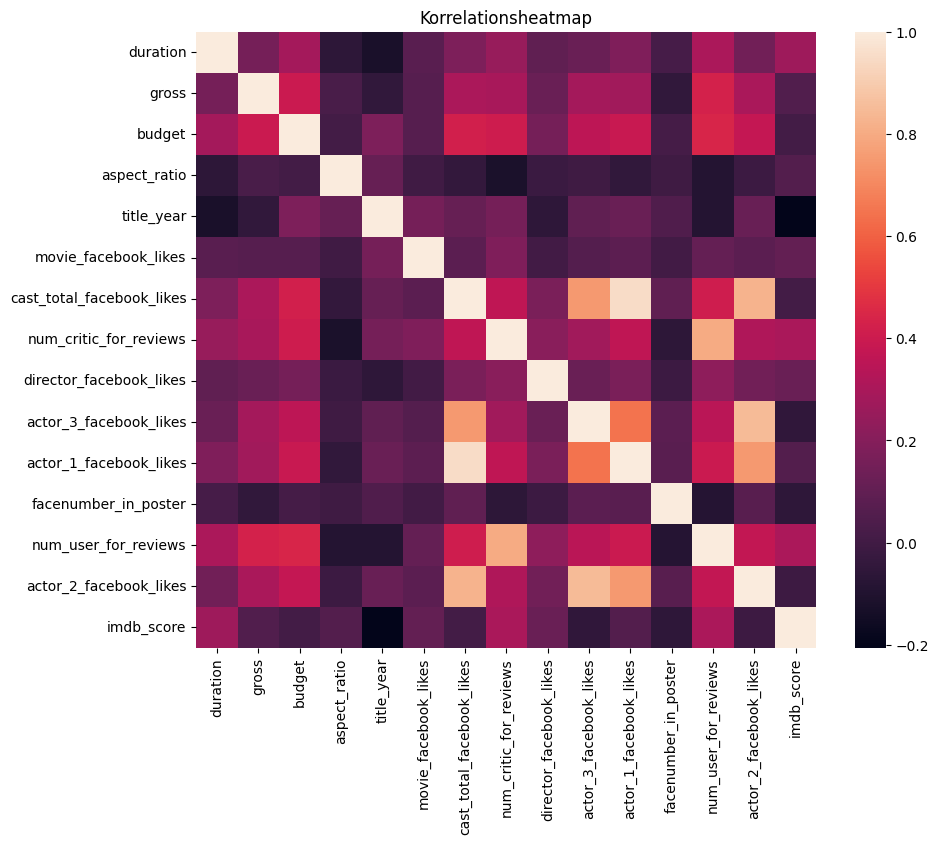

In [42]:
# Heatmap Korrelationen
plt.figure(figsize=(10,8))
sns.heatmap(train_df_scaled[num_cols + ['imdb_score']].corr(numeric_only=True))
plt.title('Korrelationsheatmap')

## Baseline

Ganz einfache Referenz - DummyRegressor (mean)

In [53]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train_scaled, y_train)

pred_baseline = baseline.predict(X_val_scaled)

print("Baseline MAE:", mean_absolute_error(y_val, pred_baseline))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_val, pred_baseline)))
print("Baseline R²:", r2_score(y_val, pred_baseline))

Baseline MAE: 0.865115877251501
Baseline RMSE: 1.114283103761567
Baseline R²: -0.005819992400383667


## Linear Regression

In [44]:
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

# Validation Linear Regression

In [45]:
y_val_pred = model.predict(X_val_scaled)

print(
    "Validation Linear Regression MSE:",
    mean_squared_error(y_val, y_val_pred)
)

print(
    "Validation Linear Regression MAE:",
    mean_absolute_error(y_val, y_val_pred)
)

print(
    "Validation Linear Regression R²:",
    r2_score(y_val, y_val_pred)
)

Validation Linear Regression MSE: 0.7119356741714885
Validation Linear Regression MAE: 0.6107291252544202
Validation Linear Regression R²: 0.42327347153763206


# Test Linear Regression

In [46]:
y_test_pred = model.predict(X_test_scaled)

print(
    "Test Linear Regression MSE:",
    mean_squared_error(y_test, y_test_pred)
)

print(
    "Test Linear Regression MAE:",
    mean_absolute_error(y_test, y_test_pred)
)

print(
    "Test Linear Regression R²:",
    r2_score(y_test, y_test_pred)
)

Test Linear Regression MSE: 0.6853556240950757
Test Linear Regression MAE: 0.61233187631904
Test Linear Regression R²: 0.44994811360631526


# Ridge Regression 
Improvement - mit Ridge können wir Multikollinearität stabilisieren und Overfitting reduzieren, da wir viele korrelierte Features haben. 

In [47]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
# alpha steuert die Stärke der Regularisierung.
# Höheres alpha bedeutet stärkere Bestrafung großer Koeffizienten
ridge_model.fit(X_train_scaled, y_train)

Ridge()

# Validation Ridge Regression 

In [48]:
y_val_ridge = ridge_model.predict(X_val_scaled)
print("MAE Ridge:", mean_absolute_error(y_val, y_val_ridge))
print("RMSE Ridge:", np.sqrt(mean_squared_error(y_val, y_val_ridge)))
print("R² Ridge:", r2_score(y_val, y_val_ridge))


MAE Ridge: 0.6078955953601339
RMSE Ridge: 0.8383942710289578
R² Ridge: 0.43058909886092167


# Test Linear Regression 

In [49]:
y_test_ridge = ridge_model.predict(X_test_scaled)

print("MAE Ridge:", mean_absolute_error(y_test, y_test_ridge))
print("RMSE Ridge:", np.sqrt(mean_squared_error(y_test, y_test_ridge)))
print("R² Ridge:", r2_score(y_test, y_test_ridge))

MAE Ridge: 0.6116981409037427
RMSE Ridge: 0.8273805301629199
R² Ridge: 0.45058783503507116


# Coefficients analysis
Die Koeffizientenanalyse (Nach dem Ridge Training) zeigt, dass Genres wie Documentary positiv mit IMDb-Score korrelieren, während Reality-TV und Game-Show eher negative Einflüsse besitzen.

Ein positiver Koeffizient bedeutet: Das Feature erhöht tendenziell den vorhergesagten IMDb-Score.
Ein negativer Koeffizient bedeutet: Das Feature senkt tendenziell den vorhergesagten IMDb-Score.

Je größer der Betrag des Koeffizienten ist, desto stärker beeinflusst das Feature die Vorhersage.

Dabei können wir wichtige Features erkennen, den Einfluss einzelner Variablen besser verstehen, oder mögliche Probleme wie Overfitting oder Multikollinearität erkennen.

Da viele Features durch One-Hot-Encoding entstanden sind, müssen die Koeffizienten vorsichtig interpretiert werden. 

Besonders seltene Kategorien können sehr große Koeffizienten erhalten, obwohl nur wenige Beispiele im Datensatz vorhanden sind (z.B Filme aus Iran usw).

Die Ridge Regression sollte dabei extrem große Koeffizienten reduzieren und das Modell stabiler machen.


In [50]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": ridge_model.coef_
})

coef_df["Abs"] = coef_df["Coefficient"].abs()

coef_sorted = coef_df.sort_values(
    by="Abs",
    ascending=False
).head(20)

print(coef_sorted)

                      Feature  Coefficient       Abs
26                  Game-Show    -1.017599  1.017599
21                Documentary     0.893154  0.893154
42            language_French     0.734436  0.734436
50       content_rating_Other     0.545478  0.545478
36                      Short    -0.487656  0.487656
17                  Animation     0.460196  0.460196
22                      Drama     0.459884  0.459884
43             language_Other     0.450779  0.450779
33                 Reality-TV    -0.445188  0.445188
28                     Horror    -0.437625  0.437625
32                       News     0.411828  0.411828
0      num_critic_for_reviews     0.350717  0.350717
47                 country_UK     0.337860  0.337860
15                     Action    -0.291108  0.291108
46              country_Other     0.280360  0.280360
53           content_rating_R     0.257430  0.257430
4      actor_1_facebook_likes     0.230859  0.230859
7   cast_total_facebook_likes    -0.205742  0.

# Coefficients Visualisation 

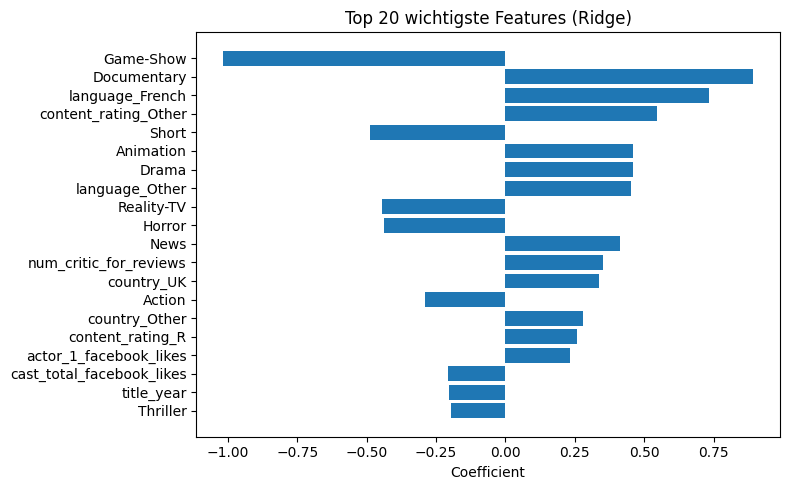

In [51]:


plt.figure(figsize=(8,5))
plt.barh(coef_sorted["Feature"][::-1], coef_sorted["Coefficient"][::-1])
plt.title("Top 20 wichtigste Features (Ridge)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

### Interpretation (für Koeffizientenanalyse nach dem Ridge Regression): 

**Documentary** als Genre hat einen positiven Koeffizienten - Dokumentationen im Datensatz tendenziell höhere IMDb-Scores haben.

**Game-Show**, **Reality-TV**, **Horror** und **Short Films** haben negative Koeffizienten und sind mit niedrigeren Bewertungen verbunden.

Einige Sprach- und Länder-Features haben auch einen positiven Einfluss. Zum Beispiel, haben **French** und **United Kingdom** positive Koeffizienten. 

Bei den numerischen Features zeigt **Number of Critics** einen positiven Zusammenhang mit dem IMDb-Score. Das bedeutet, dass Filme mit mehr Kritikerbewertungen tendenziell besser bewertet werden. Dagegen haben **Year** und **Total Facebook Likes** einen leicht negativen Einfluss.

Insgesamt sind die Koeffizienten der Ridge Regression stabil und gut interpretierbar. Sie helfen zu verstehen, welche Merkmale den größten Einfluss auf die Vorhersage des IMDb-Scores haben. Die Koeffizienten zeigen jedoch nur Zusammenhänge im Modell und keine Ursache-Wirkungs-Beziehungen.


In [52]:
# Einige Features mit den höchsten Koeffizienten sind eher selten. Das wird nochmal geprüft:

# Länder
country_cols = [c for c in X_train_scaled.columns if c.startswith("country_")]
print("Top Länder:")
print(X_train_scaled[country_cols].sum().sort_values(ascending=False).head(20))

print("\n" + "="*50 + "\n")

# Sprachen
language_cols = [c for c in X_train_scaled.columns if c.startswith("language_")]
print("Top Sprachen:")
print(X_train_scaled[language_cols].sum().sort_values(ascending=False).head(20))

print("\n" + "="*50 + "\n")

# Ratings
rating_cols = [c for c in X_train_scaled.columns if c.startswith("content_rating_")]
print("Top Ratings:")
print(X_train_scaled[rating_cols].sum().sort_values(ascending=False))

Top Länder:
country_USA        2243
country_UK          266
country_Other       250
country_France       98
country_Germany      59
dtype: int64


Top Sprachen:
language_Other     153
language_French     52
dtype: int64


Top Ratings:
content_rating_R            1450
content_rating_PG-13         872
content_rating_PG            408
content_rating_Other         137
content_rating_Not Rated      68
dtype: int64


# Random Forest mit Grid Search

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [57]:
# Bestes Modell

best_rf = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


# Validation Random Forest

In [60]:
y_val_pred_rf = best_rf.predict(X_val_scaled)

print(
    "Validation Random Forest MSE:",
    mean_squared_error(y_val, y_val_pred_rf)
)

print(
    "Validation Random Forest MAE:",
    mean_absolute_error(y_val, y_val_pred_rf)
)

print(
    "Validation Random Forest R²:",
    r2_score(y_val, y_val_pred_rf)
)

Validation Random Forest MSE: 0.5306795954768062
Validation Random Forest MAE: 0.5302455551018425
Validation Random Forest R²: 0.5701058228591727


# Test Random Forest

In [61]:
y_test_pred_rf = best_rf.predict(X_test_scaled)

print(
    "Validation Random Forest MSE:",
    mean_squared_error(y_test, y_test_pred_rf)
)

print(
    "Validation Random Forest MAE:",
    mean_absolute_error(y_test, y_test_pred_rf)
)

print(
    "Validation Random Forest R²:",
    r2_score(y_test, y_test_pred_rf)
)

Validation Random Forest MSE: 0.5416950706943366
Validation Random Forest MAE: 0.5303001732614607
Validation Random Forest R²: 0.5652470264922698


# Feature Importance Random Forest

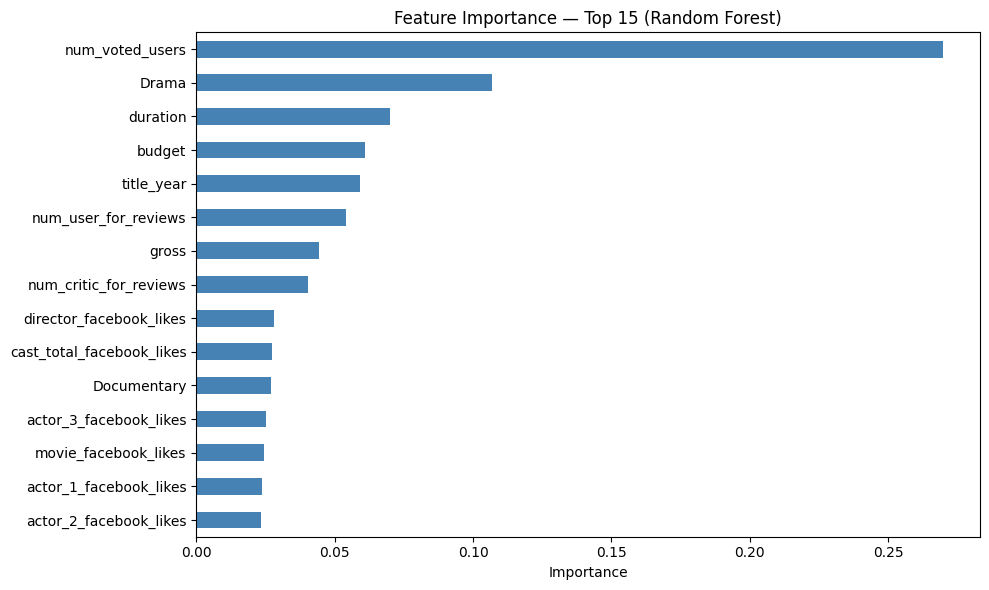


Die wichtigsten diagnostischen Merkmale:
num_voted_users              0.270
Drama                        0.107
duration                     0.070
budget                       0.061
title_year                   0.059
num_user_for_reviews         0.054
gross                        0.044
num_critic_for_reviews       0.040
director_facebook_likes      0.028
cast_total_facebook_likes    0.028
Documentary                  0.027
actor_3_facebook_likes       0.025
movie_facebook_likes         0.024
actor_1_facebook_likes       0.024
actor_2_facebook_likes       0.023


In [62]:

importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Top 15 (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nDie wichtigsten diagnostischen Merkmale:')
print(top15.round(3).to_string())